## Roughness scaling: analysis

_Loads the pre-computed slimmed summary produced by `roughness_scale-load-compute`. All heavy simulation arrays (hc, vc, veg …) have been dropped._

TODO See if we do better with smaller roughness contrast. larger range of storm parameters.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import os as _os
import sys
import shutil
import itertools as it
import contextlib
from scipy.optimize import minimize
from sklearn.preprocessing import MinMaxScaler
import statsmodels.formula.api as smf
import json
from scipy.stats import gmean
import pandas as pd

sys.path.append("/Users/octaviacrompton/Projects/roughness-scale/swof_code")


import matplotlib.cm as _cm
import matplotlib.colors as _mcolors

In [2]:
# ── Figure registry (src/figure_registry.py) ──────────────────────────────────
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
import figure_registry as _fig_reg

# Expose convenience names so all figure-saving cells work unchanged
_fig_dirs              = _fig_reg._fig_dirs
update_figure_registry = _fig_reg.update_figure_registry

# Note: call _fig_reg.configure(out_dir) once out_dir is set (see data-load cell)

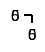

In [3]:
my_modules = ['plot_SWOF', "read_SWOF", "write_SWOF", 
              "plot_config", "topo", "source_functions_1p3"]

for mod in my_modules:
    if mod in sys.modules: 
        del sys.modules[mod] 

from plot_SWOF import *
from read_SWOF import *
from plot_config import *
from topo import *
from write_SWOF import *
from source_functions_1p3 import *


In [4]:
project_dir = "/Users/octaviacrompton/Dropbox/FullCSWOF/Tests/"
cases = [d for d in os.listdir(project_dir) if 
            ('DS_Store' not in d) and ('figures' not in d)]


In [5]:

# out_dir must match what was used in roughness_scale-load-compute
out_dir   = os.path.join(project_dir, 'runaround_smooth')
slim_path = os.path.join(out_dir, 'summary_slim.pkl')

summary = pd.read_pickle(slim_path)
print(f'Loaded summary_slim: shape = {summary.shape}')
print('Columns:', sorted(summary.columns.tolist()))

# initialise figure registry for this session
_fig_reg.configure(out_dir, notebook_name='roughness_scale-analysis.ipynb')

Loaded summary_slim: shape = (1440, 330)
Columns: ['$p t_r$', '<Sf>', '<Sf>_C_Uphp_lin', '<Sf>_C_nphp_lin', '<Sf>_T0', '<Sf>_T0_hyb', '<Sf>_T1', '<Sf>_T2', '<Sf>_Ubar2_np2', '<Sf>_cross_nU', '<Sf>_direct', '<Sf>_direct_minus_exp2', '<Sf>_direct_wet', '<Sf>_exp2', '<Sf>_hyb_Up2', '<Sf>_hyb_base', '<Sf>_hyb_cross', '<Sf>_hyb_np2', '<Sf>_hyb_num_sum', '<Sf>_hybrid_quad', '<Sf>_nbar2_Ubar2', '<Sf>_nbar2_Up2', '<Sf>_nd_T0', '<Sf>_nd_T1', '<Sf>_nd_T2', '<Sf>_nd_sumK2', '<Sf>_series2', '<U dU/dx>', '<U>', '<U>/<h>', '<U><dU/dx>', '<U>^2/<Up^2>', '<U>_CF', '<Ua>', '<Uh>', '<Up dUp/dx>', '<Up hp>', '<Up2>', '<dU/dx>', '<dh/dx>', '<dhp/dx>', '<eta ups>', '<eta2>', '<h>', '<h>_CF', '<h^2/3>', '<ha>', '<hp2>', '<n2>', '<n2><h>^-4/3', '<n>', '<n>2', '<n><U>', '<nU>', '<na>', '<np Up>', '<np hp>', '<np2>', '<q>_direct', '<q>_hform', '<q>_uform', '<r eta>', '<r ups>', '<r2>', '<ups2>', 'B_bc_NF', 'B_bc_init', 'Bbound', 'C', 'CPU_time', 'Cd', 'Cd_misc', 'Choice_dt_specific_points', 'Choice_points', 'F

In [6]:
# ── Variable naming / display labels ──────────────────────────────────────────
# Shared labels, colour maps, and helpers live in src/labels.py
import sys as _sys
_sys.path.insert(0, "/Users/octaviacrompton/Projects/roughness-scale/src")
from labels import (
    updates, rename, renameit,
    VEG_COLORS, VEG_LABELS,
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VAR_CMAPS,
    format_name as _format_name_raw,
)

# Wrap format_name so callers don't need to pass `names` explicitly
def format_name(fld, updates=updates):
    return _format_name_raw(fld, names, updates=updates)

summary['LB_std'] = [l.std() for l in summary.LB_dist]

# ── Toggle: set USE_HYDRO = True to make 'effect_ratio' use hydrograph-based n_e
USE_HYDRO = False
if USE_HYDRO:
    summary['effect']       = summary['effect_hydro']
    summary['effect_ratio'] = summary['effect_ratio_hydro']


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='minutes', ylabel='cm/hr'>)

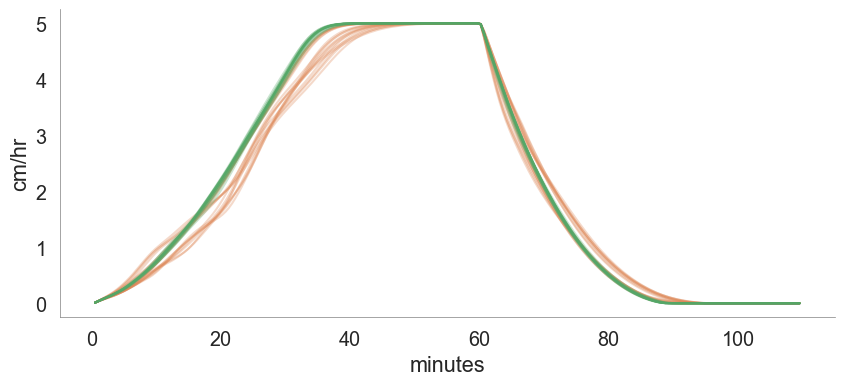

In [7]:

fig, ax = plt.subplots(1, figsize = (10,4))


subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV == 0.6 and sigma >3  ")
plot_hydrographs(subset, c= 'C1', ax =ax)

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV == 0.6 and sigma <3 ")
plot_hydrographs(subset, c= 'C2', ax =ax)


0.6
0.95


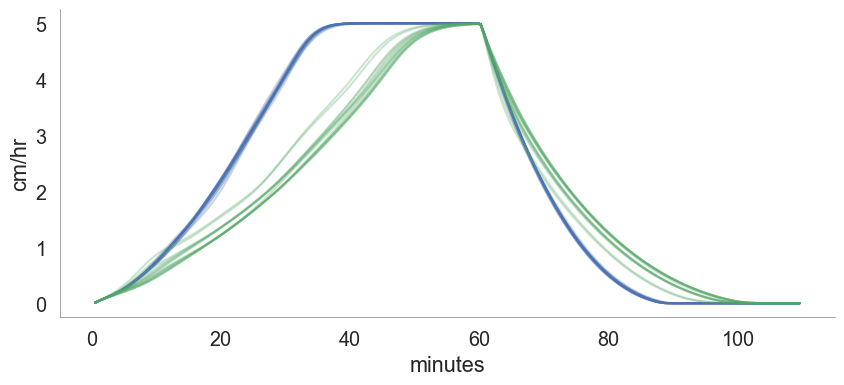

In [8]:
fig, ax = plt.subplots(1, figsize = (10,4))

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and effect_ratio < 0.65 ")
plot_hydrographs(subset, c= 'C0', ax =ax)
print ((subset.fV.max()))

subset = summary.query("hydro_err < 0.05 and p == 8 and tr == 60 and l == 200 and fV > 0.45 and  effect_ratio > 0.95 ")
plot_hydrographs(subset, c= 'C2', ax =ax)
print ((subset.fV.max()))


##  Spatial pattern 
_Scatter plots and summaries of how vegetation pattern (σ, fV, aniso) drives the spatial heterogeneity and the effect ratio. Run **after** slimming the dataframe._

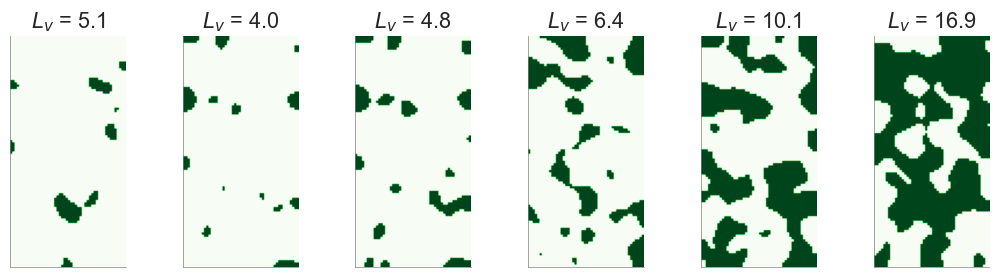

In [9]:
if 'veg_type' in summary.columns and (summary['veg_type'] == 'blob').any():
    fig, axes = plt.subplots(1,6,figsize = (13, 3) )
    axes = axes.ravel()
    for i, key in enumerate(summary.query("L > 10 and L < 500 and sigma == 3 and aniso == 1 and veg_type == 'blob'").sort_values('fV').index[::10][:6]):
        sim = summary.loc[key]
        axes[ i].imshow(sim.veg.T[:100], cmap = "Greens")
        axes[i].imshow(sim.veg.T[:100], cmap = "Greens")

        bin_max = np.maximum(sim.LB_dist.max(), sim.L_dc_dist.max())

        axes[i].set_xticks([])
        axes[i].set_yticks([])
        axes[i].set_title("$L_v$ = {0:.1f}".format(sim.LV))


In [10]:
_band_mask = summary['veg_type'].str.contains('band')
summary.loc[_band_mask, 'aniso'] = 1
summary.loc[_band_mask, 'stripe_count'] = summary.loc[_band_mask, 'l'] / summary.loc[_band_mask, 'sigma']
summary['effect_ratio_exp3'] = summary['n_exp3'] / summary['<n>']

_blob_mask = summary['veg_type'] == 'blob'
summary.loc[_blob_mask, 'stripe_count'] = summary.loc[_blob_mask, 'aniso']


In [11]:
# ── Parameters ────────────────────────────────────────────────────────────────
fV      = 0.6   # centre of fV window
fV_half = 0.05  # half-width → selects fV in [fV - fV_half, fV + fV_half]
hue_var = None  # None = auto: 'aniso' if only blobs, else 'veg_type'


def _build_hue_info(df, hue_var):
    """Return (plot_hue_col, palette, label_order, hue_label) for the given hue variable."""
    _veg_types = df['veg_type'].unique()
    if hue_var is None:
        hue_var = 'aniso' if set(_veg_types) == {'blob'} else 'veg_type'

    if hue_var == 'veg_type':
        palette = {k: v for k, v in VEG_COLORS.items() if k in _veg_types}
        _fallback = iter(_cm.tab10.colors)
        for vt in _veg_types:
            if vt not in palette:
                palette[vt] = next(_fallback)
        return hue_var, palette, None, 'veg type'

    if hue_var == 'aniso':
        _aniso_name = {v: ('gradient-aligned' if v < 0 else
                           'isotropic'        if v == 1 else
                           'contour-aligned') for v in sorted(df['aniso'].unique())}
        df['_aniso_label'] = df['aniso'].map(_aniso_name)
        _label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                        if l in df['_aniso_label'].unique()]
        _aniso_vals = sorted(_aniso_name.keys())
        _bg_cmap = _mcolors.LinearSegmentedColormap.from_list(
            'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641'])
        _norm = _mcolors.Normalize(vmin=min(_aniso_vals), vmax=max(_aniso_vals))
        palette = {_aniso_name[v]: _bg_cmap(_norm(v)) for v in _aniso_vals}
        return '_aniso_label', palette, _label_order, 'Orientation'

    return hue_var, 'viridis', None, hue_var


def _dedup_legend(handles, labels):
    """Return handles/labels with duplicate labels removed (keep first)."""
    seen, out_h, out_l = set(), [], []
    for h, l in zip(handles, labels):
        if l not in seen:
            seen.add(l); out_h.append(h); out_l.append(l)
    return out_h, out_l


# ── Filter + hue setup ────────────────────────────────────────────────────────
_df = summary[(summary['fV'] >= fV - fV_half) & (summary['fV'] <= fV + fV_half)].copy()

if _df.empty:
    print(f"No data in fV window [{fV - fV_half}, {fV + fV_half}]. "
          f"Available fV: {sorted(summary['fV'].unique())}")
else:
    _is_band    = _df['veg_type'].str.contains('band').any()
    _plot_hue, _palette, _label_order, _hue_label = _build_hue_info(_df, hue_var)

    _marker_pool = ['^', 'o', 's', 'D', 'P', 'X', 'v', '<', '>']
    _hue_vals    = list(_palette.keys()) if isinstance(_palette, dict) else sorted(_df[_plot_hue].unique())
    _markers     = {v: _marker_pool[i % len(_marker_pool)] for i, v in enumerate(_hue_vals)}


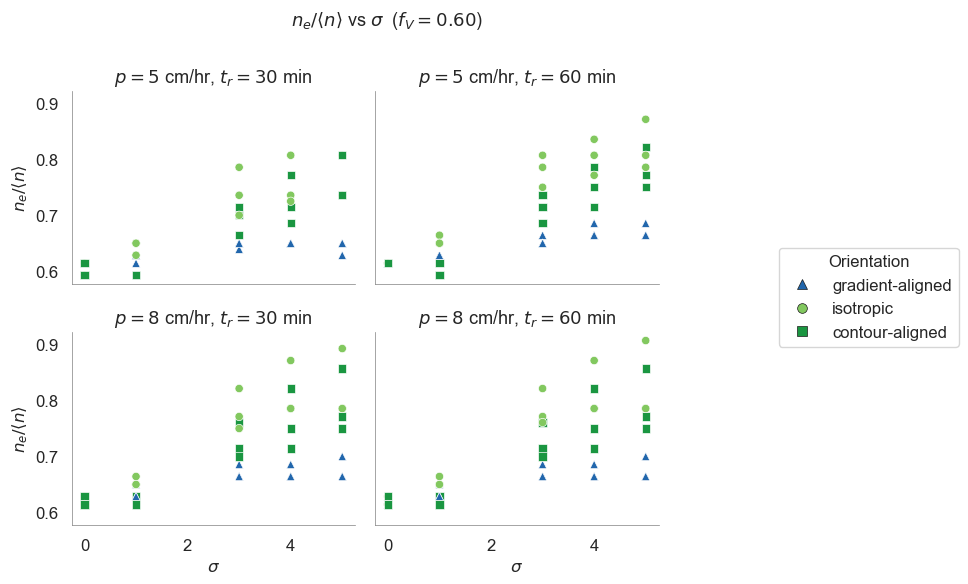

In [18]:
# ── Plot: effect_ratio vs sigma, faceted by (p, tr) ──────────────────────────
if not _df.empty:
    from matplotlib.lines import Line2D

    p_vals  = sorted(_df['p'].unique())
    tr_vals = sorted(_df['tr'].unique())
    nrows, ncols = len(p_vals), len(tr_vals)

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows),
                             sharex=True, sharey=True)
    axes = np.array(axes).reshape(nrows, ncols)

    for ri, p in enumerate(p_vals):
        for ci, tr in enumerate(tr_vals):
            ax  = axes[ri, ci]
            sub = _df[(_df['p'] == p) & (_df['tr'] == tr)]
            if sub.empty:
                ax.set_visible(False)
                continue

            sns.scatterplot(
                data=sub,
                x='sigma', y='effect_ratio',
                hue=_plot_hue,
                style=_plot_hue,
                markers=_markers,
                palette=_palette,
                ax=ax,
                legend=False,
            )

            ax.set_title(f"$p={p}$ cm/hr, $t_r={tr}$ min", fontsize=FS_TITLE)
            ax.set_xlabel(("band count" if _is_band else r"$\sigma$") if ri == nrows - 1 else "",
                          fontsize=FS_LABEL)
            ax.set_ylabel(renameit('effect_ratio', rename) if ci == 0 else "", fontsize=FS_LABEL)
            ax.tick_params(labelsize=FS_TICK)

    # Figure-level legend
    _legend_values = _label_order if (_plot_hue == '_aniso_label' and _label_order is not None) else _hue_vals
    _legend_handles = []
    for v in _legend_values:
        _color = _palette[v] if isinstance(_palette, dict) else 'gray'
        _label = VEG_LABELS.get(v, v) if _plot_hue == 'veg_type' else v
        _legend_handles.append(
            Line2D([0], [0], marker=_markers[v], linestyle='None',
                   markerfacecolor=_color, markeredgecolor='k', markeredgewidth=0.5,
                   markersize=7, label=_label)
        )

    fig.legend(
        handles=_legend_handles,
        loc='center left',
        bbox_to_anchor=(0.98, 0.5),
        title=_hue_label,
        frameon=True,
        fontsize=FS_LEG,
        title_fontsize=FS_LEG,
    )

    fig.suptitle(
        fr"$n_e/\langle n \rangle$ vs $\sigma$  ($f_V = {fV:.2f}$)",
        fontsize=FS_TITLE,
    )
    plt.tight_layout()
    plt.subplots_adjust(right=0.84)


In [13]:
if not _df.empty:
    _fig_dir, _, _ = _fig_dirs()
    _name = 'fig3_effect_ratio_vs_sigma_grid.png'
    fig.savefig(_os.path.join(_fig_dir, _name), dpi=300, bbox_inches='tight')
    update_figure_registry(
        'fig3', _name,
        description=(
            r"$n_e/\langle n \rangle$ vs $\sigma$ for all simulations at "
            r"$f_V \approx 0.6$, organised in a grid of panels by rainfall intensity "
            r"($p$, rows) and storm duration ($t_r$, columns). "
            r"Points are coloured and shaped by vegetation arrangement type (or "
            r"anisotropy when only blob patterns are present)."
        ),
        concise=(
            r"Effect ratio vs sigma at fV≈0.6, panelled by p×tr, coloured by veg type / anisotropy. "
            r"Reveals how spatial heterogeneity (sigma) and storm forcing jointly "
            r"control the effective-roughness enhancement."
        ),
    )


Registry updated → ../figures/runaround_smooth/figure_registry.txt  [fig3]


In [14]:
# effect_ratio vs fV — two panels: least and most intense storm, coloured by sigma
_cc_df = summary.query("hydro_err < 0.03").copy()
_cc_df['_d'] = _cc_df['p'] * _cc_df['tr'] / 60   # storm depth (mm)

# Pick the (p, tr) combos with min and max storm depth
_combos = _cc_df.groupby(['p', 'tr'])['_d'].first().reset_index()
_lo = _combos.loc[_combos['_d'].idxmin(), ['p', 'tr']]
_hi = _combos.loc[_combos['_d'].idxmax(), ['p', 'tr']]
_storm_pairs = [(_lo['p'], _lo['tr']), (_hi['p'], _hi['tr'])]

# Sigma colour scale (mako)
_sigma_levels = sorted(_cc_df['sigma'].unique())
_mako = _cm.get_cmap('mako')
_sigma_norm = _mcolors.Normalize(vmin=0, vmax=max(_sigma_levels))
_sigma_palette = {s: _mako(_sigma_norm(s)) for s in _sigma_levels}

fig_cc, axes_cc = plt.subplots(1, 2, figsize=(10, 4),
                               sharex=True, sharey=True, squeeze=False)

for ci, (p, tr) in enumerate(_storm_pairs):
    ax  = axes_cc[0, ci]
    sub = _cc_df[(_cc_df['p'] == p) & (_cc_df['tr'] == tr)]
    _show_leg = (ci == 1)
    _d_val = p * tr / 60
    sns.scatterplot(data=sub, x='fV', y='effect_ratio', ax=ax,
                    hue='sigma', hue_order=_sigma_levels,
                    palette=_sigma_palette, s=60, alpha=0.8,
                    legend=_show_leg)
    _intensity = 'most intense' if ci == 1 else 'least intense'
    ax.set_title(f"$p={p}$ mm/hr, $t_r={tr}$ min  ({_intensity})", fontsize=FS_TITLE)
    ax.set_xlabel(renameit('fV'), fontsize=FS_LABEL)
    ax.set_ylabel(renameit('effect_ratio') if ci == 0 else '', fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)
    if _show_leg:
        leg = ax.get_legend()
        if leg: leg.remove()
        hs, ls = ax.get_legend_handles_labels()
        ax.legend(hs, ls, title=renameit('sigma'), fontsize=FS_LEG,
                  title_fontsize=FS_LEG, loc='upper left',
                  bbox_to_anchor=(1.02, 1), borderaxespad=0)

plt.tight_layout()


TypeError: reduction operation 'argmin' not allowed for this dtype

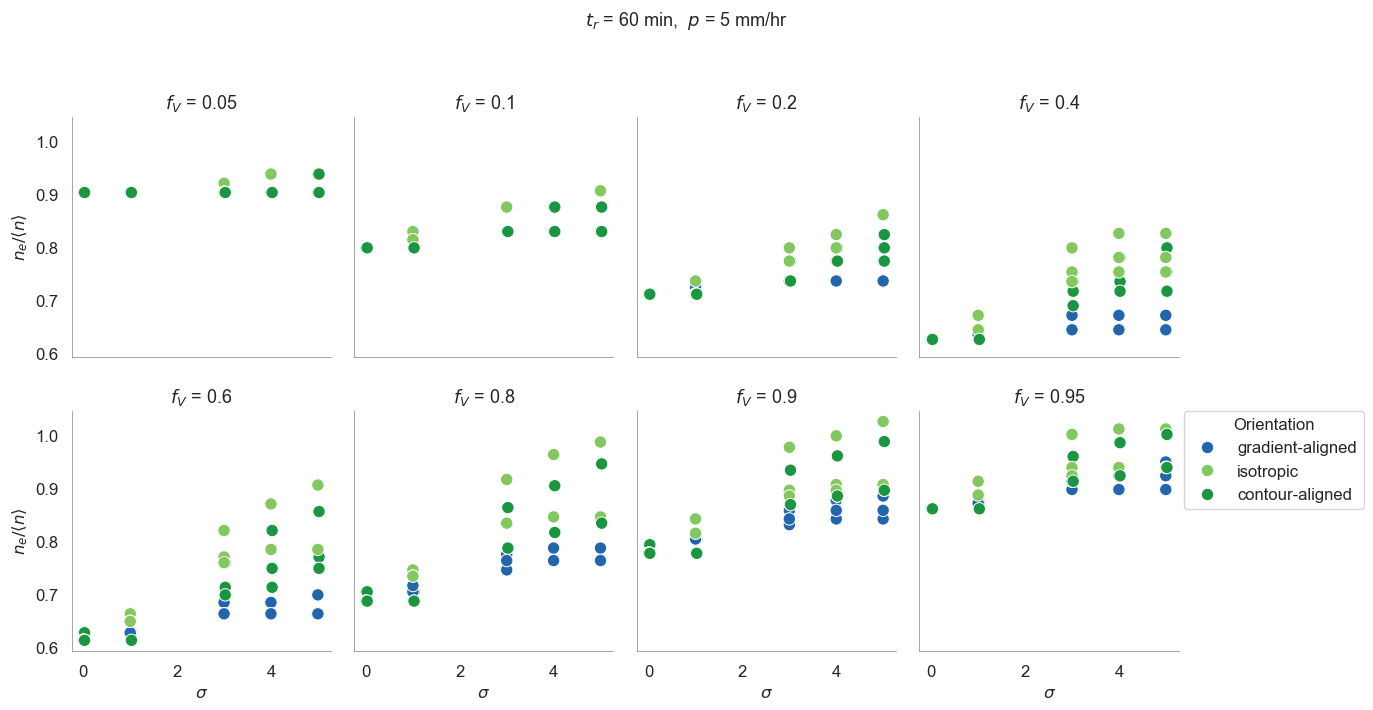

In [ ]:

# sigma vs effect_ratio — one panel per fV value, 2 rows × 4 cols
_ncols = 4
_df = summary.query("hydro_err < 0.05 and tr == 60 and p == 8").copy()
_fv_vals = sorted(_df['fV'].unique())
_nrows = 2

# ── Anisotropy labels + palette (same as _build_hue_info) ────────────────────
_aniso_name = {v: ('gradient-aligned' if v < 0 else
                   'isotropic'        if v == 1 else
                   'contour-aligned') for v in sorted(_df['aniso'].unique())}
_df['_aniso_label'] = _df['aniso'].map(_aniso_name)
_label_order = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                if l in _df['_aniso_label'].unique()]
_bg_cmap = _mcolors.LinearSegmentedColormap.from_list(
    'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641'])
_aniso_vals = sorted(_aniso_name.keys())
_norm = _mcolors.Normalize(vmin=min(_aniso_vals), vmax=max(_aniso_vals))
_aniso_palette = {_aniso_name[v]: _bg_cmap(_norm(v)) for v in _aniso_vals}

# add small jitter on sigma for contour-aligned to reduce overplotting
_df.loc[_df['_aniso_label'] == 'contour-aligned', 'sigma'] += 0.025

fig, axes = plt.subplots(_nrows, _ncols, figsize=(14, 7), sharey=True, sharex=True)
axes_flat = axes.flatten()

for i, fv in enumerate(_fv_vals):
    ax = axes_flat[i]
    _sub = _df[_df['fV'] == fv]
    _show_leg = (i == len(_fv_vals) - 1)
    sns.scatterplot(_sub, x='sigma', y='effect_ratio', ax=ax,
                    hue='_aniso_label', hue_order=_label_order,
                    palette=_aniso_palette, s=80, legend=_show_leg)
    ax.set_title(f"$f_V$ = {fv:.2g}", fontsize=FS_TITLE)
    ax.set_xlabel(renameit('sigma') if i >= _ncols else '', fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)

# y-labels on left column only
for ri in range(_nrows):
    axes[ri, 0].set_ylabel(renameit('effect_ratio'), fontsize=FS_LABEL)
    for ci in range(1, _ncols):
        axes[ri, ci].set_ylabel('')

# Hide any unused axes
for ax in axes_flat[len(_fv_vals):]:
    ax.set_visible(False)

# Legend outside last panel
if axes_flat[len(_fv_vals) - 1].get_legend():
    axes_flat[len(_fv_vals) - 1].legend(
        title='Orientation', fontsize=FS_LEG, title_fontsize=FS_LEG,
        bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.suptitle("$t_r$ = 60 min,  $p$ = 5 mm/hr", y=1.02, fontsize=FS_TITLE)
plt.tight_layout()


In [15]:

# --- filter and make a working copy
query = "hydro_err < 0.05 and tr == 60 and p == 8"
subset = summary.query(query).copy()

# --- your deliberate shifts (since `tr == 60` is already in the query,
#     these apply to the whole subset)
subset["l"]     = subset["l"] + 10
subset["sigma"] = subset["sigma"].astype(int) 

# --- round σ to two decimals and force ordered categorical for clean ticks
subset["sigma"] = subset["sigma"].astype(float).round(2)
sigma_order = np.sort(subset["sigma"].dropna().unique())
subset["sigma"] = pd.Categorical(subset["sigma"], categories=sigma_order, ordered=True)

# --- rename columns for pretty axis labels (keeps numeric values intact)
subset = subset.rename(columns=rename)

xfld = renameit("sigma")          # r"$\sigma$"
yfld = renameit("effect_ratio")   # r"$n_e/\langle n \rangle$"
cfld = renameit("aniso")          # "anisotropic"


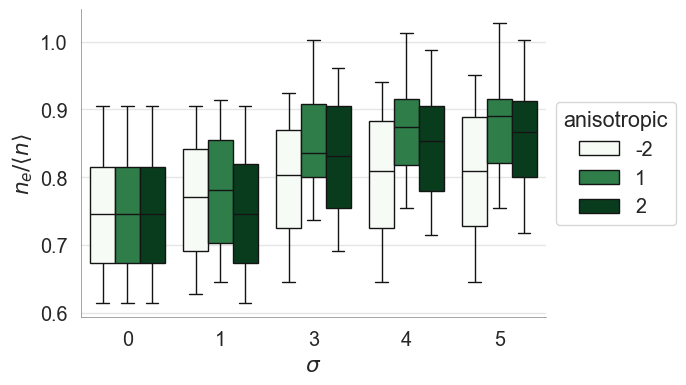

In [16]:

plt.figure(figsize=(6, 4))
ax = sns.boxplot(
    data=subset,
    x=xfld,
    y=yfld,
    hue=cfld,
    order=sigma_order,  # use the exact σ categories as tick order
    palette="Greens",
    dodge=True
)

# format ticks exactly as your rounded σ values
ax.set_xticklabels([f"{v:.0f}" for v in sigma_order])

# legend
ax.legend(loc="center left", title="anisotropic", bbox_to_anchor=(1.0, 0.5), ncol=1)
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel(r"$n_e/\langle n \rangle$")
ax.grid(axis="y", alpha=0.2)


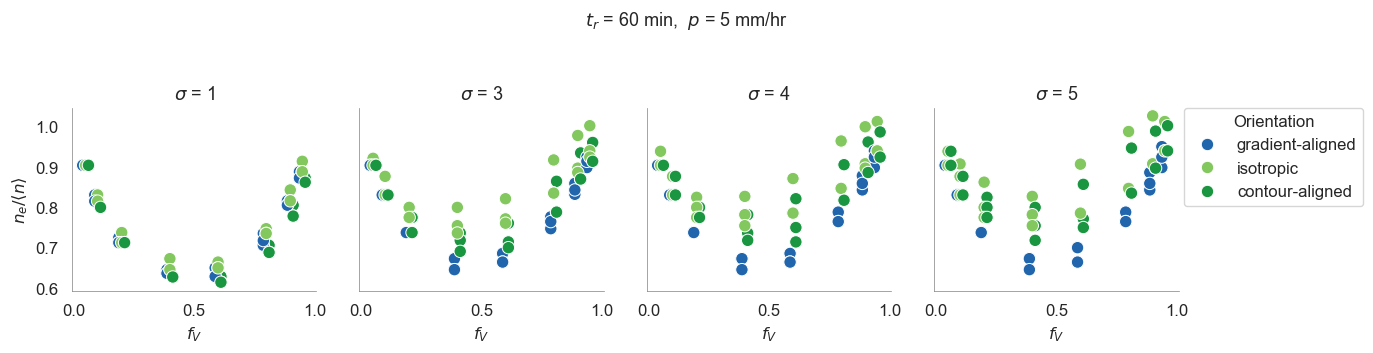

In [17]:

# effect_ratio vs fV — one panel per sigma value (σ>0), 1 row × 4 cols
_ncols2 = 4
_df2 = summary.query("hydro_err < 0.05 and tr == 60 and p == 8 and sigma > 0").copy()
_sigma_vals = sorted(_df2['sigma'].unique())
_nrows2 = 1

# ── Same anisotropy labels + palette ─────────────────────────────────────────
_aniso_name2 = {v: ('gradient-aligned' if v < 0 else
                    'isotropic'        if v == 1 else
                    'contour-aligned') for v in sorted(_df2['aniso'].unique())}
_df2['_aniso_label'] = _df2['aniso'].map(_aniso_name2)
_label_order2 = [l for l in ['gradient-aligned', 'isotropic', 'contour-aligned']
                 if l in _df2['_aniso_label'].unique()]
_bg_cmap2 = _mcolors.LinearSegmentedColormap.from_list(
    'blue_green', ['#2166ac', '#92c5de', '#a6d96a', '#1a9641'])
_aniso_vals2 = sorted(_aniso_name2.keys())
_norm2 = _mcolors.Normalize(vmin=min(_aniso_vals2), vmax=max(_aniso_vals2))
_aniso_palette2 = {_aniso_name2[v]: _bg_cmap2(_norm2(v)) for v in _aniso_vals2}

# x-axis offsets so the three orientation categories separate cleanly
_fv_offsets = {'gradient-aligned': -0.012, 'isotropic': 0.0, 'contour-aligned': +0.012}
for _lbl, _dx in _fv_offsets.items():
    _df2.loc[_df2['_aniso_label'] == _lbl, 'fV'] += _dx

fig2, axes2 = plt.subplots(_nrows2, _ncols2, figsize=(14, 3.5),
                           sharey=True, sharex=True, squeeze=False)
axes2_flat = axes2.flatten()

for i, sigma in enumerate(_sigma_vals):
    ax = axes2_flat[i]
    _sub = _df2[_df2['sigma'] == sigma]
    _show_leg = (i == len(_sigma_vals) - 1)
    sns.scatterplot(_sub, x='fV', y='effect_ratio', ax=ax,
                    hue='_aniso_label', hue_order=_label_order2,
                    palette=_aniso_palette2, s=80, legend=_show_leg)
    ax.set_title(f"$\\sigma$ = {sigma:.3g}", fontsize=FS_TITLE)
    ax.set_xlabel(renameit('fV'), fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK)

# y-labels on left column only
for ri in range(_nrows2):
    axes2[ri, 0].set_ylabel(renameit('effect_ratio'), fontsize=FS_LABEL)
    for ci in range(1, _ncols2):
        axes2[ri, ci].set_ylabel('')

# Hide any unused axes
for ax in axes2_flat[len(_sigma_vals):]:
    ax.set_visible(False)

# Legend outside last panel
if axes2_flat[len(_sigma_vals) - 1].get_legend():
    axes2_flat[len(_sigma_vals) - 1].legend(
        title='Orientation', fontsize=FS_LEG, title_fontsize=FS_LEG,
        bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.suptitle("$t_r$ = 60 min,  $p$ = 5 mm/hr", y=1.02, fontsize=FS_TITLE)
plt.tight_layout()


## Sensitivity to storm characteristics

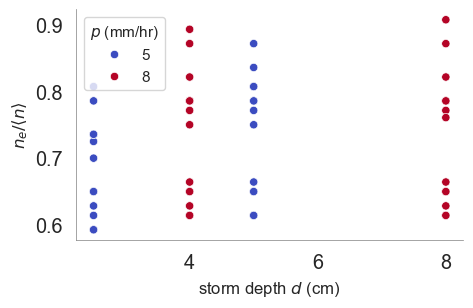

In [ ]:
summary['d'] = summary['p'] * summary['tr'] / 60
ax = sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 "),
                     x='d', y='effect_ratio', hue='p', palette='coolwarm')
ax.set_xlabel(r"storm depth $d$ (cm)", fontsize=12)
ax.set_ylabel(rename.get('effect_ratio', r'$n_e/\langle n \rangle$'), fontsize=12)
ax.legend(title=r"$p$ (mm/hr)", fontsize=11, title_fontsize=11)
# sns.scatterplot(summary.query("fV == 0.6 and aniso == 1 and sigma ==5 "), x='p', y='effect_ratio')

_, _scratch, _ = _fig_dirs()
ax.get_figure().savefig(_os.path.join(_scratch, 'storm_depth_vs_effect_ratio.png'),
                        dpi=200, bbox_inches='tight')
